# Task 3 - Customer Segmentation
**Dataset:** Cleaned Telco Customer Churn (from Task 1)  
In this task, I performed customer segmentation using selected features from the cleaned dataset.

The objective is to group customers based on characteristics such as tenure, monthly charges, and contract type, and analyze churn behavior within each segment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('cleaned_churn_data.csv')
print("Dataset loaded:", df.shape)
df[['customerID','tenure','MonthlyCharges','Contract','Churn']].head()

Dataset loaded: (7043, 21)


,customerID,tenure,MonthlyCharges,Contract,Churn
0,7590-VHVEG,1,29.85,Month-to-month,0
1,5575-GNVDE,34,56.95,One year,0
2,3668-QPYBK,2,53.85,Month-to-month,1
3,7795-CFOCW,45,42.30,One year,0
4,9237-HQITU,2,70.70,Month-to-month,1


## Section 1: Segmentation by Tenure
In this section, I segmented customers based on tenure (number of months with the company).

Customers were grouped into three categories:
- New (0–12 months)
- Mid-term (13–36 months)
- Long-term (37+ months)

In [2]:
# using pd.cut() to bin continuous tenure values into labelled groups
df['Tenure_Segment'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 36, 72],
    labels=['New (0-12m)', 'Mid-term (13-36m)', 'Long-term (37+m)'],
    include_lowest=True
)

print("Customer count per tenure segment:")
print(df['Tenure_Segment'].value_counts())

Customer count per tenure segment:
Tenure_Segment
Long-term (37+m)     3001
New (0-12m)          2186
Mid-term (13-36m)    1856
Name: count, dtype: int64


In [3]:
# churn rate per segment
tenure_stats = df.groupby('Tenure_Segment', observed=True).agg(
    Customers=('customerID', 'count'),
    Churned=('Churn', 'sum'),
    Churn_Rate_Pct=('Churn', lambda x: round(x.mean()*100, 1)),
    Avg_Monthly_Charge=('MonthlyCharges', lambda x: round(x.mean(), 1))
).reset_index()

print("Tenure Segment Analysis:")
print(tenure_stats.to_string(index=False))

Tenure Segment Analysis:
   Tenure_Segment  Customers  Churned  Churn_Rate_Pct  Avg_Monthly_Charge
      New (0-12m)       2186     1037            47.4                56.1
Mid-term (13-36m)       1856      474            25.5                63.2
 Long-term (37+m)       3001      358            11.9                72.0


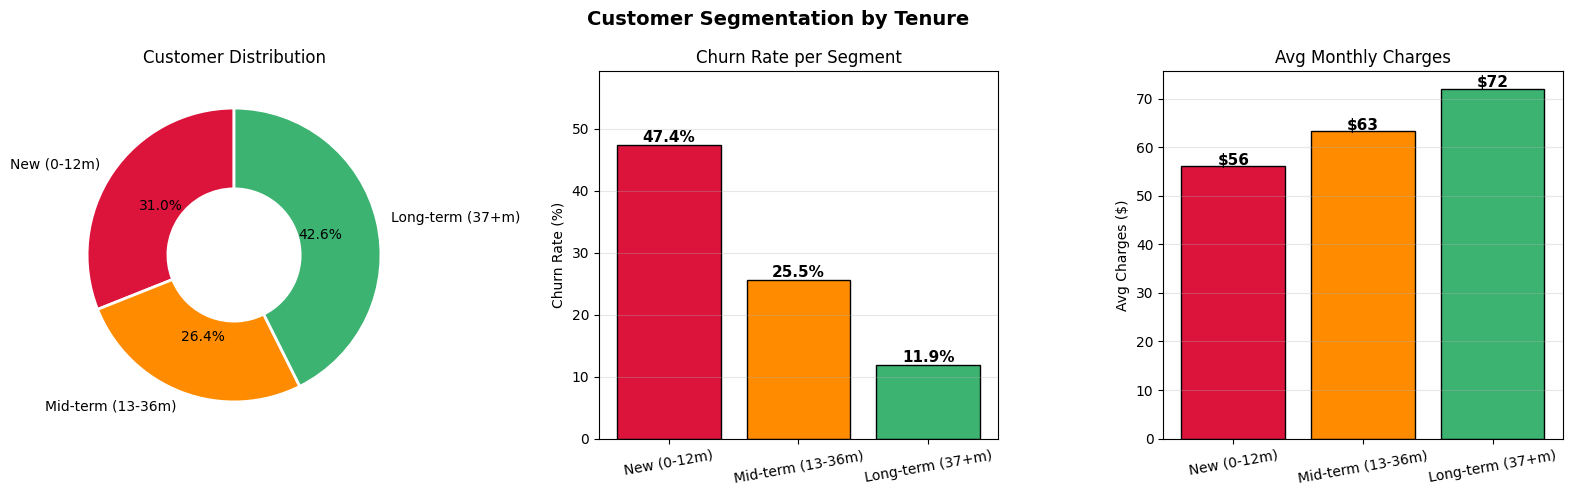

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Customer Segmentation by Tenure', fontsize=14, fontweight='bold')

seg_colors = ['crimson', 'darkorange', 'mediumseagreen']
segs = ['New (0-12m)', 'Mid-term (13-36m)', 'Long-term (37+m)']

# pie - distribution of customers across segments
counts = df['Tenure_Segment'].value_counts().reindex(segs)
axes[0].pie(counts.values, labels=segs, colors=seg_colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'width':0.55,'edgecolor':'white','linewidth':2})
axes[0].set_title('Customer Distribution')

# churn rate per segment
churn_rates = df.groupby('Tenure_Segment', observed=True)['Churn'].mean().mul(100).reindex(segs)
bars = axes[1].bar(segs, churn_rates.values, color=seg_colors, edgecolor='black')
for bar, val in zip(bars, churn_rates.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Churn Rate per Segment')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, churn_rates.max()*1.25)
axes[1].tick_params(axis='x', rotation=10)
axes[1].grid(axis='y', alpha=0.3)

# avg monthly charges
charges = df.groupby('Tenure_Segment', observed=True)['MonthlyCharges'].mean().reindex(segs)
bars2 = axes[2].bar(segs, charges.values, color=seg_colors, edgecolor='black')
for bar, val in zip(bars2, charges.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'${val:.0f}', ha='center', fontweight='bold', fontsize=11)
axes[2].set_title('Avg Monthly Charges')
axes[2].set_ylabel('Avg Charges ($)')
axes[2].tick_params(axis='x', rotation=10)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('seg_01_tenure.png', bbox_inches='tight', dpi=120)
plt.show()

## Section 2: Cross-Segment Heatmap (Tenure × Contract Type)
Here, I used a pivot table and heatmap to examine churn distribution across tenure and contract type combinations.

In [5]:
# pivot table - churn rate for each tenure + contract combination
pivot = df.pivot_table(
    values='Churn',
    index='Tenure_Segment',
    columns='Contract',
    aggfunc='mean',
    observed=True
) * 100

print("Churn rate (%) by Tenure x Contract:")
print(pivot.round(1))
print()
print("Insight: New customer + Month-to-month is the most dangerous combination")

Churn rate (%) by Tenure x Contract:
Contract           Month-to-month  One year  Two year
Tenure_Segment                                       
New (0-12m)                  51.4      10.5       0.0
Mid-term (13-36m)            35.7       8.1       1.1
Long-term (37+m)             29.6      13.0       3.2

Insight: New customer + Month-to-month is the most dangerous combination


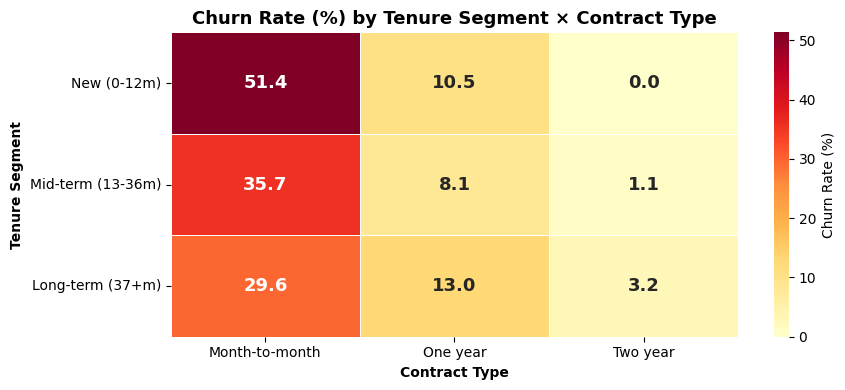

In [6]:
plt.figure(figsize=(9, 4))
sns.heatmap(
    pivot, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    annot_kws={'size':13, 'weight':'bold'},
    cbar_kws={'label':'Churn Rate (%)'}
)
plt.title('Churn Rate (%) by Tenure Segment × Contract Type', fontsize=13, fontweight='bold')
plt.xlabel('Contract Type', fontweight='bold')
plt.ylabel('Tenure Segment', fontweight='bold')
plt.tight_layout()
plt.savefig('seg_02_heatmap.png', bbox_inches='tight', dpi=120)
plt.show()

## Section 3: Segmentation by Charges
Here, customers were grouped based on monthly charges to compare churn rates across charge categories.

In [7]:
df['Charge_Segment'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 35, 65, 200],
    labels=['Low (<$35)', 'Medium ($35-65)', 'High (>$65)']
)

charge_stats = df.groupby('Charge_Segment', observed=True).agg(
    Customers=('customerID','count'),
    Churn_Rate_Pct=('Churn', lambda x: round(x.mean()*100,1))
).reset_index()

print("Segmentation by Monthly Charges:")
print(charge_stats.to_string(index=False))
print()
print("High-paying customers churn more - they likely have fibre optic and multiple services")

Segmentation by Monthly Charges:
 Charge_Segment  Customers  Churn_Rate_Pct
     Low (<$35)       1735            10.9
Medium ($35-65)       1409            23.1
    High (>$65)       3899            34.7

High-paying customers churn more - they likely have fibre optic and multiple services


## Section 4: Customer Risk Score
In this section, I developed a simple risk scoring approach based on key factors identified during exploratory analysis.

Each customer was assigned points based on selected attributes associated with higher churn rates.
Scoring criteria:

- Tenure ≤ 12 months: +3 points
- Month-to-month contract: +3 points
- Monthly charges > $65: +2 points
- No partner: +1 point
- No dependents: +1 point
- Electronic check payment method: +1 point

The maximum possible score is 11. Higher scores indicate relatively higher churn risk.

In [8]:
df['Risk_Score'] = (
    (df['tenure'] <= 12).astype(int) * 3 +
    (df['Contract'] == 'Month-to-month').astype(int) * 3 +
    (df['MonthlyCharges'] > 65).astype(int) * 2 +
    (df['Partner'] == 'No').astype(int) * 1 +
    (df['Dependents'] == 'No').astype(int) * 1 +
    (df['PaymentMethod'] == 'Electronic check').astype(int) * 1
)

print("Risk Score distribution:")
print(df['Risk_Score'].value_counts().sort_index())
print()
print("Score range:", df['Risk_Score'].min(), "to", df['Risk_Score'].max())

Risk Score distribution:
Risk_Score
0     503
1     377
2     901
3     765
4     659
5     520
6     529
7     718
8     922
9     326
10    353
11    470
Name: count, dtype: int64

Score range: 0 to 11


In [9]:
# grouping scores into 4 risk tiers
df['Risk_Tier'] = pd.cut(
    df['Risk_Score'],
    bins=[-1, 2, 5, 7, 11],
    labels=['Low Risk', 'Moderate Risk', 'High Risk', 'Critical Risk']
)

# validating the score actually works do higher tiers have higher real churn?
risk_validation = df.groupby('Risk_Tier', observed=True).agg(
    Customers=('customerID','count'),
    Actual_Churn_Rate=('Churn', lambda x: round(x.mean()*100,1))
).reset_index()

print("Risk Score Validation:")
print(risk_validation.to_string(index=False))
print()
print("Validation passed if churn rate increases with each tier")

Risk Score Validation:
    Risk_Tier  Customers  Actual_Churn_Rate
     Low Risk       1781                3.6
Moderate Risk       1944               13.0
    High Risk       1247               33.9
Critical Risk       2071               54.5

Validation passed if churn rate increases with each tier


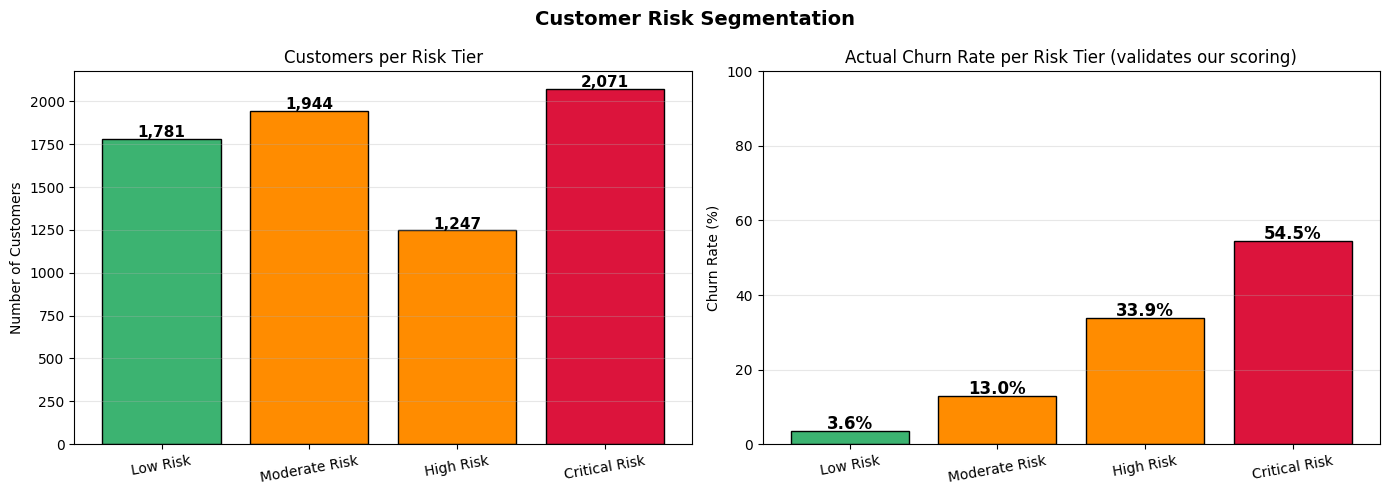

In [10]:
tier_order = ['Low Risk', 'Moderate Risk', 'High Risk', 'Critical Risk']
risk_colors = ['mediumseagreen', 'darkorange', 'darkorange', 'crimson']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Customer Risk Segmentation', fontsize=14, fontweight='bold')

# customer count per tier
tier_counts = df['Risk_Tier'].value_counts().reindex(tier_order)
bars = axes[0].bar(tier_order, tier_counts.values, color=risk_colors, edgecolor='black')
for bar, val in zip(bars, tier_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Customers per Risk Tier')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=10)
axes[0].grid(axis='y', alpha=0.3)

# actual churn rate per tier - validates the score
churn_by_tier = df.groupby('Risk_Tier', observed=True)['Churn'].mean().mul(100).reindex(tier_order)
bars2 = axes[1].bar(tier_order, churn_by_tier.values, color=risk_colors, edgecolor='black')
for bar, val in zip(bars2, churn_by_tier.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Actual Churn Rate per Risk Tier (validates our scoring)')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('seg_03_risk_tiers.png', bbox_inches='tight', dpi=120)
plt.show()

In [11]:
# saving enriched data for use in later tasks
df.to_csv('segmented_churn_data.csv', index=False)
print("Saved segmented_churn_data.csv")
print()

critical = df[df['Risk_Tier'] == 'Critical Risk']
print(f"Critical risk customers: {len(critical)}")
print(f"Their actual churn rate: {critical['Churn'].mean()*100:.1f}%")
print()
print("Task 3 complete!")

Saved segmented_churn_data.csv

Critical risk customers: 2071
Their actual churn rate: 54.5%

Task 3 complete!
